In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# stable config
config = {
    "seed": 42,
    "batch_size": 32,
    "img_size": 128
}
random.seed(config["seed"])
np.random.seed(config["seed"])
torch.manual_seed(config["seed"])

project_root = "/content/drive/MyDrive/5207"
data_root = os.path.join(project_root, "data", "Rock-Paper-Scissors")
train_dir = os.path.join(data_root, "train")
val_dir = os.path.join(data_root, "validation")
test_dir = os.path.join(data_root, "test")
runs_dir = os.path.join(project_root, "runs")
os.makedirs(runs_dir, exist_ok=True)

print("project root:", project_root)
print("data root:", data_root)
print("train dir exists:", os.path.exists(train_dir))
print("val dir exists:", os.path.exists(val_dir))
print("test dir exists:", os.path.exists(test_dir))
print("config:", config)

project root: /content/drive/MyDrive/dsai5207
data root: /content/drive/MyDrive/dsai5207/data/Rock-Paper-Scissors
train dir exists: True
val dir exists: True
test dir exists: True
config: {'seed': 42, 'batch_size': 32, 'img_size': 128}


***1. Data Pipline***

1.1 Loading & checking dataset

In [ ]:
# Loading dataset
transform = transforms.Compose([
    transforms.Resize((config["img_size"], config["img_size"])),
    transforms.ToTensor()
])
# print(os.listdir(data_root))
train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset = datasets.ImageFolder(val_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)

print("train size =", len(train_dataset))
print("val size   =", len(val_dataset))
print("test size  =", len(test_dataset))
print("class map  =", train_dataset.class_to_idx)

# Checking dataset
idx_to_class = {}
for name, idx in train_dataset.class_to_idx.items():
    idx_to_class[idx] = name

def count_by_class(dataset):
    counts = {}
    for _, label in dataset.samples:
        cls_name = idx_to_class[label]
        if cls_name not in counts:
            counts[cls_name] = 0
        counts[cls_name] += 1
    return counts

train_counts = count_by_class(train_dataset)
val_counts = count_by_class(val_dataset)
test_counts = count_by_class(test_dataset)
print("train counts:", train_counts)
print("val counts:", val_counts)
print("test counts:", test_counts)

dist_df = pd.DataFrame({
    "train": pd.Series(train_counts),
    "validation": pd.Series(val_counts),
    "test": pd.Series(test_counts)
}).fillna(0).astype(int)

dist_path = os.path.join(runs_dir, "dataset_distribution.csv")
dist_df.to_csv(dist_path)
print("saved:", dist_path)
dist_df

train size = 2520
val size   = 33
test size  = 372
class map  = {'paper': 0, 'rock': 1, 'scissors': 2}
train counts: {'paper': 840, 'rock': 840, 'scissors': 840}
val counts: {'paper': 11, 'rock': 11, 'scissors': 11}
test counts: {'paper': 124, 'rock': 124, 'scissors': 124}
saved: /content/drive/MyDrive/dsai5207/runs/dataset_distribution.csv


,train,validation,test
paper,840,11,124
rock,840,11,124
scissors,840,11,124


1.2 Grasp 2 graphs from different types and see the distribution

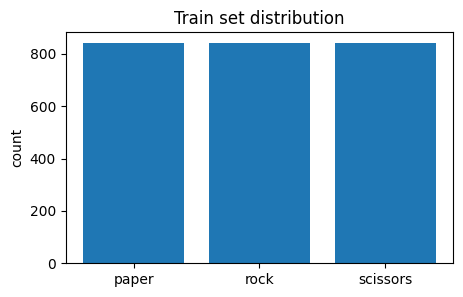

chosen_idx length: 6


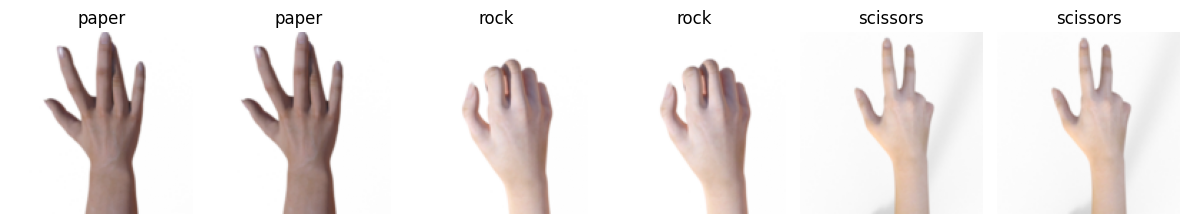

In [ ]:
# plot the types distribution
fig1, ax1 = plt.subplots(figsize=(5, 3))
ax1.bar(train_counts.keys(), train_counts.values())
ax1.set_title("Train set distribution")
ax1.set_ylabel("count")
plt.show()

# grasp 2 graphs from different types
# samples_by_class = {"paper": [], "rock": [], "scissors": []}

# grasp 2 graphs from different types automatically
class_names = list(train_dataset.class_to_idx.keys())
samples_by_class = {c: [] for c in class_names}

for idx, (_, label) in enumerate(train_dataset.samples):
    cls_name = idx_to_class[label]
    if len(samples_by_class[cls_name]) < 2:
        samples_by_class[cls_name].append(idx)

# from paper, rock to scissors
# chosen_idx = (
#     samples_by_class["paper"] +
#     samples_by_class["rock"] +
#     samples_by_class["scissors"]
# )

# combining the names together
chosen_idx = []
for c in class_names:
    chosen_idx += samples_by_class[c]
print("chosen_idx length:", len(chosen_idx))

fig2, axes = plt.subplots(1, 6, figsize=(12, 3))
for i, idx in enumerate(chosen_idx):
    img, label = train_dataset[idx]
    img = img.permute(1, 2, 0).numpy()
    axes[i].imshow(img)
    axes[i].set_title(idx_to_class[label])
    axes[i].axis("off")
plt.tight_layout()
plt.show()

1.3 Low-data sampling function(with **5%, 10%, 20%, 50%, 100%** training subset)

In [ ]:
def sample_subset(dataset, ratio, config):
    total_num = len(dataset)
    picked_num = int(total_num * ratio)
    all_idx = list(range(total_num))
    rng = random.Random(config["seed"])
    rng.shuffle(all_idx)
    picked_idx = all_idx[:picked_num]
    subset = Subset(dataset, picked_idx)
    return subset

ratios = [0.05, 0.10, 0.20, 0.50, 1.0]
for r in ratios:
    if r == 1.0:
        cur_data = train_dataset
    else:
        cur_data = sample_subset(train_dataset, r, config)
    print("ratio =", r, "->", len(cur_data))

ratio = 0.05 -> 126
ratio = 0.1 -> 252
ratio = 0.2 -> 504
ratio = 0.5 -> 1260
ratio = 1.0 -> 2520


1.4 API of the DataLoader & Save the data size information

In [ ]:
def get_dataloaders(ratio, config):
    if ratio == 1.0:
        train_data = train_dataset
    else:
        train_data = sample_subset(train_dataset, ratio, config)
    train_loader = DataLoader(
        train_data,
        batch_size=config["batch_size"],
        shuffle=True
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=config["batch_size"],
        shuffle=False
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=config["batch_size"],
        shuffle=False
    )

    return train_loader, val_loader, test_loader

size_rows = []
for r in [0.05, 0.10, 0.20, 0.50, 1.0]:
    if r == 1.0:
        train_data = train_dataset
    else:
        train_data = sample_subset(train_dataset, r, config)
    size_rows.append({
        "ratio": r,
        "train_size": len(train_data),
        "val_size": len(val_dataset),
        "test_size": len(test_dataset)
    })

size_df = pd.DataFrame(size_rows)
size_path = os.path.join(runs_dir, "dataset_sizes.csv")
size_df.to_csv(size_path, index=False)
print("saved:", size_path)
size_df

saved: /content/drive/MyDrive/dsai5207/runs/dataset_sizes.csv


,ratio,train_size,val_size,test_size
0,0.05,126,33,372
1,0.10,252,33,372
2,0.20,504,33,372
3,0.50,1260,33,372
4,1.00,2520,33,372


Quick test of the API

In [ ]:
current_ratio = 0.10 # ratio is alternative
print("ratio:", current_ratio)
print("batch_size (fixed):", config["batch_size"])
print("seed (fixed):", config["seed"])

train_loader, val_loader, test_loader = get_dataloaders(current_ratio, config)
for x, y in train_loader:
    print("x shape:", x.shape)
    print("y shape:", y.shape)
    break

ratio: 0.1
batch_size (fixed): 32
seed (fixed): 42
x shape: torch.Size([32, 3, 128, 128])
y shape: torch.Size([32])


***2. MLP Baseline + Main Experiments***


2.1 Setup device, folders and training config


In [ ]:
from copy import deepcopy
from sklearn.metrics import f1_score
import torch.nn as nn
import torch.optim as optim

models_dir = os.path.join(project_root, "models")
os.makedirs(models_dir, exist_ok=True)

mlp_config = deepcopy(config)
mlp_config.update({
    "epochs": 15,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "hidden_dims": [512, 128],
    "dropout": 0.30,
    "num_classes": len(train_dataset.classes)
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("mlp_config:", mlp_config)
print("models dir:", models_dir)


device: cuda
mlp_config: {'seed': 42, 'batch_size': 32, 'img_size': 128, 'epochs': 15, 'lr': 0.001, 'weight_decay': 0.0001, 'hidden_dims': [512, 128], 'dropout': 0.3, 'num_classes': 3}
models dir: /content/drive/MyDrive/dsai5207/models


2.2 Define the MLP baseline (flatten image input first)


In [ ]:
class MLPBaseline(nn.Module):
    def __init__(self, input_shape=(3, 128, 128), hidden_dims=(512, 128), num_classes=3, dropout=0.3):
        super().__init__()
        c, h, w = input_shape
        input_dim = c * h * w

        layers = [nn.Flatten()]
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, num_classes))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

sample_model = MLPBaseline(
    input_shape=(3, mlp_config["img_size"], mlp_config["img_size"]),
    hidden_dims=tuple(mlp_config["hidden_dims"]),
    num_classes=mlp_config["num_classes"],
    dropout=mlp_config["dropout"]
)
print(sample_model)


MLPBaseline(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=49152, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=128, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=128, out_features=3, bias=True)
  )
)


2.3 Training / validation / test functions


In [ ]:
def run_one_epoch(model, loader, criterion, optimizer=None, device="cpu"):
    is_train = optimizer is not None
    model.train()  # set train mode if is_train else model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            logits = model(images)
            loss = criterion(logits, labels)
            if is_train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "macro_f1": macro_f1
    }

# basic training function for one ratio
def train_mlp(train_loader, val_loader, ratio, exp_config, device):
    model = MLPBaseline(
        input_shape=(3, exp_config["img_size"], exp_config["img_size"]),
        hidden_dims=tuple(exp_config["hidden_dims"]),
        num_classes=exp_config["num_classes"],
        dropout=exp_config["dropout"]
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        model.parameters(),
        lr=exp_config["lr"],
        weight_decay=exp_config["weight_decay"]
    )

    history = []
    best_val_acc = -1.0
    best_state = None

    for epoch in range(1, exp_config["epochs"] + 1):
        train_metrics = run_one_epoch(model, train_loader, criterion, optimizer=optimizer, device=device)
        val_metrics = run_one_epoch(model, val_loader, criterion, optimizer=None, device=device)

        row = {
            "model": "MLP",
            "data_ratio": ratio,
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "train_macro_f1": train_metrics["macro_f1"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_macro_f1": val_metrics["macro_f1"]
        }
        history.append(row)

        print(
            f"[MLP][ratio={ratio:.2f}] epoch {epoch:02d}/{exp_config['epochs']} | "
            f"train_loss={train_metrics['loss']:.4f}, train_acc={train_metrics['accuracy']:.4f}, "
            f"val_loss={val_metrics['loss']:.4f}, val_acc={val_metrics['accuracy']:.4f}, "
            f"val_f1={val_metrics['macro_f1']:.4f}"
        )

        if val_metrics["accuracy"] > best_val_acc:
            best_val_acc = val_metrics["accuracy"]
            best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history)


2.4 Main experiments over 5%, 10%, 20%, 50%, 100% and save outputs


In [ ]:
ratios = [0.05, 0.10, 0.20, 0.50, 1.0]

mlp_log_path = os.path.join(runs_dir, "mlp_training_log.csv")
results_raw_path = os.path.join(runs_dir, "results_raw.csv")
expected_ratio_model_paths = [
    os.path.join(models_dir, f"mlp_ratio_{int(r * 100):03d}.pt") for r in ratios
]

use_saved_mlp = (
    os.path.exists(mlp_log_path)
    and os.path.exists(results_raw_path)
    and all(os.path.exists(p) for p in expected_ratio_model_paths)
)

if use_saved_mlp:
    print("Found saved MLP results. Skip training and load from local files.")
    mlp_log_df = pd.read_csv(mlp_log_path)

    results_df = pd.read_csv(results_raw_path)
    if "model" in results_df.columns:
        results_df = results_df[results_df["model"] == "MLP"].copy()

    print("Loaded training log from:", mlp_log_path)
    print("Loaded result table from:", results_raw_path)
else:
    all_logs = []
    all_results = []

    for ratio in ratios:
        print("=" * 80)
        print(f"Start MLP experiment | ratio = {ratio}")

        train_loader, val_loader, test_loader = get_dataloaders(ratio, mlp_config)
        model, history_df = train_mlp(train_loader, val_loader, ratio, mlp_config, device)
        test_metrics = run_one_epoch(
            model,
            test_loader,
            criterion=nn.CrossEntropyLoss(),
            optimizer=None,
            device=device
        )

        history_df["test_accuracy_at_best_val_model"] = test_metrics["accuracy"]
        history_df["test_macro_f1_at_best_val_model"] = test_metrics["macro_f1"]
        all_logs.append(history_df)

        result_row = {
            "data_ratio": ratio,
            "model": "MLP",
            "accuracy": test_metrics["accuracy"],
            "macro_f1": test_metrics["macro_f1"]
        }
        all_results.append(result_row)

        ratio_model_path = os.path.join(models_dir, f"mlp_ratio_{int(ratio * 100):03d}.pt")
        torch.save(model.state_dict(), ratio_model_path)
        print(f"saved ratio model: {ratio_model_path}")
        print(f"test accuracy = {test_metrics['accuracy']:.4f}, test macro_f1 = {test_metrics['macro_f1']:.4f}")

        if ratio == 1.0:
            final_model_path = os.path.join(models_dir, "mlp_model.pt")
            torch.save(model.state_dict(), final_model_path)
            print(f"saved final MLP baseline model: {final_model_path}")

    mlp_log_df = pd.concat(all_logs, ignore_index=True)
    mlp_log_df.to_csv(mlp_log_path, index=False)
    print("saved:", mlp_log_path)

    results_df = pd.DataFrame(all_results)
    if os.path.exists(results_raw_path):
        old_results_df = pd.read_csv(results_raw_path)
        results_df = pd.concat([old_results_df, results_df], ignore_index=True)
        results_df = results_df.drop_duplicates(subset=["data_ratio", "model"], keep="last")
    results_df.to_csv(results_raw_path, index=False)
    print("saved:", results_raw_path)

results_df

Found saved MLP results. Skip training and load from local files.
Loaded training log from: /content/drive/MyDrive/dsai5207/runs/mlp_training_log.csv
Loaded result table from: /content/drive/MyDrive/dsai5207/runs/results_raw.csv


,data_ratio,model,accuracy,macro_f1
0,0.05,MLP,0.408602,0.299445
1,0.10,MLP,0.287634,0.199863
2,0.20,MLP,0.333333,0.166667
3,0.50,MLP,0.333333,0.166667
4,1.00,MLP,0.333333,0.166667


2.5 Quick check of training log and final MLP results


In [ ]:
print("Training log preview:")
display(mlp_log_df.head())

print("Final MLP results:")
display(results_df[results_df["model"] == "MLP"].sort_values("data_ratio"))


Training log preview:


,model,data_ratio,epoch,train_loss,train_accuracy,train_macro_f1,val_loss,val_accuracy,val_macro_f1,test_accuracy_at_best_val_model,test_macro_f1_at_best_val_model
0,MLP,0.05,1,14.120173,0.357143,0.350751,5.406295,0.333333,0.166667,0.408602,0.299445
1,MLP,0.05,2,9.327452,0.301587,0.300823,5.222628,0.333333,0.166667,0.408602,0.299445
2,MLP,0.05,3,6.175950,0.396825,0.376733,2.729030,0.333333,0.166667,0.408602,0.299445
3,MLP,0.05,4,3.269364,0.412698,0.403742,1.828271,0.333333,0.166667,0.408602,0.299445
4,MLP,0.05,5,2.766249,0.349206,0.330116,1.268368,0.333333,0.166667,0.408602,0.299445


Final MLP results:


,data_ratio,model,accuracy,macro_f1
0,0.05,MLP,0.408602,0.299445
1,0.10,MLP,0.287634,0.199863
2,0.20,MLP,0.333333,0.166667
3,0.50,MLP,0.333333,0.166667
4,1.00,MLP,0.333333,0.166667


In [ ]:
improved_config = {
    "seed": 42,
    "batch_size": 32,
    "img_size": 64,
    "epochs": 20,
    "lr": 5e-4,
    "weight_decay": 1e-4,
    "dropout": 0.3,
    "num_classes": 3,
    "patience": 5
}

random.seed(improved_config["seed"])
np.random.seed(improved_config["seed"])
torch.manual_seed(improved_config["seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(improved_config["seed"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("improved_config:", improved_config)

# make sure these paths already exist from previous sections
print("train_dir:", train_dir)
print("val_dir:", val_dir)
print("test_dir:", test_dir)
print("runs_dir:", runs_dir)

models_dir = os.path.join(project_root, "models")
os.makedirs(models_dir, exist_ok=True)
print("models_dir:", models_dir)

device: cuda
improved_config: {'seed': 42, 'batch_size': 32, 'img_size': 64, 'epochs': 20, 'lr': 0.0005, 'weight_decay': 0.0001, 'dropout': 0.3, 'num_classes': 3, 'patience': 5}
train_dir: /content/drive/MyDrive/dsai5207/data/Rock-Paper-Scissors/train
val_dir: /content/drive/MyDrive/dsai5207/data/Rock-Paper-Scissors/validation
test_dir: /content/drive/MyDrive/dsai5207/data/Rock-Paper-Scissors/test
runs_dir: /content/drive/MyDrive/dsai5207/runs
models_dir: /content/drive/MyDrive/dsai5207/models


In [ ]:
improved_transform = transforms.Compose([
    transforms.Resize((improved_config["img_size"], improved_config["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

train_dataset_improved = datasets.ImageFolder(train_dir, transform=improved_transform)
val_dataset_improved = datasets.ImageFolder(val_dir, transform=improved_transform)
test_dataset_improved = datasets.ImageFolder(test_dir, transform=improved_transform)

print("improved train size =", len(train_dataset_improved))
print("improved val size   =", len(val_dataset_improved))
print("improved test size  =", len(test_dataset_improved))
print("class map           =", train_dataset_improved.class_to_idx)

improved train size = 2520
improved val size   = 33
improved test size  = 372
class map           = {'paper': 0, 'rock': 1, 'scissors': 2}


In [ ]:
def sample_subset_indices_by_ratio(full_dataset, ratio, seed=42):
    rng = random.Random(seed)
    class_to_indices = {}

    for idx, (_, label) in enumerate(full_dataset.samples):
        class_to_indices.setdefault(label, []).append(idx)

    selected_indices = []
    for label, indices in class_to_indices.items():
        indices = indices.copy()
        rng.shuffle(indices)

        k = max(1, int(len(indices) * ratio))
        selected_indices.extend(indices[:k])

    rng.shuffle(selected_indices)
    return selected_indices

def get_improved_dataloaders(ratio, cfg):
    train_indices = sample_subset_indices_by_ratio(
        train_dataset_improved, ratio, seed=cfg["seed"]
    )
    train_subset = Subset(train_dataset_improved, train_indices)

    train_loader = DataLoader(
        train_subset,
        batch_size=cfg["batch_size"],
        shuffle=True,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )

    val_loader = DataLoader(
        val_dataset_improved,
        batch_size=cfg["batch_size"],
        shuffle=False,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )

    test_loader = DataLoader(
        test_dataset_improved,
        batch_size=cfg["batch_size"],
        shuffle=False,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )

    return train_loader, val_loader, test_loader, len(train_subset)

In [ ]:
class ImprovedMLP(nn.Module):
    def __init__(self, input_dim, num_classes=3, dropout=0.3):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),

            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.network(x)

input_dim = 3 * improved_config["img_size"] * improved_config["img_size"]

tmp_model = ImprovedMLP(
    input_dim=input_dim,
    num_classes=improved_config["num_classes"],
    dropout=improved_config["dropout"]
)
print(tmp_model)

ImprovedMLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=12288, out_features=256, bias=True)
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=256, out_features=64, bias=True)
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=64, out_features=3, bias=True)
  )
)


In [ ]:
def run_one_epoch(model, loader, criterion, optimizer=None, device="cpu"):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_count = 0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            logits = model(images)
            loss = criterion(logits, labels)

            if is_train:
                loss.backward()
                optimizer.step()

        batch_size_now = labels.size(0)
        total_loss += loss.item() * batch_size_now
        total_count += batch_size_now

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

    avg_loss = total_loss / total_count
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return avg_loss, accuracy, macro_f1

In [ ]:
import copy

ratios = [0.05, 0.10, 0.20, 0.50, 1.00]

improved_log_path = os.path.join(runs_dir, "mlp_improved_training_log.csv")
improved_results_path = os.path.join(runs_dir, "results_raw_improved_mlp.csv")
expected_improved_model_paths = [
    os.path.join(models_dir, f"mlp_improved_ratio_{int(r * 100):03d}.pt") for r in ratios
]

use_saved_improved_mlp = (
    os.path.exists(improved_log_path)
    and os.path.exists(improved_results_path)
    and all(os.path.exists(p) for p in expected_improved_model_paths)
)

if use_saved_improved_mlp:
    print("Found saved Improved MLP results. Skip training and load from local files.")
    improved_log_df = pd.read_csv(improved_log_path)
    improved_results_df = pd.read_csv(improved_results_path)
    print("Loaded training log from:", improved_log_path)
    print("Loaded result table from:", improved_results_path)
else:
    improved_training_logs = []
    improved_results = []

    for ratio in ratios:
        print("=" * 80)
        print(f"Start Improved MLP experiment | ratio = {ratio}")

        train_loader, val_loader, test_loader, train_size_now = get_improved_dataloaders(
            ratio, improved_config
        )
        print(f"train subset size @ ratio={ratio}: {train_size_now}")

        model = ImprovedMLP(
            input_dim=input_dim,
            num_classes=improved_config["num_classes"],
            dropout=improved_config["dropout"]
        ).to(device)

        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=improved_config["lr"],
            weight_decay=improved_config["weight_decay"]
        )

        best_val_acc = -1.0
        best_val_f1 = -1.0
        best_state = None
        patience_counter = 0
        best_epoch = -1

        for epoch in range(1, improved_config["epochs"] + 1):
            train_loss, train_acc, train_f1 = run_one_epoch(
                model, train_loader, criterion, optimizer=optimizer, device=device
            )
            val_loss, val_acc, val_f1 = run_one_epoch(
                model, val_loader, criterion, optimizer=None, device=device
            )

            print(
                f"[ImprovedMLP][ratio={ratio:.2f}] epoch {epoch:02d}/{improved_config['epochs']} | "
                f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, train_f1={train_f1:.4f}, "
                f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}, val_f1={val_f1:.4f}"
            )

            improved_training_logs.append({
                "model": "MLP_Improved",
                "data_ratio": ratio,
                "epoch": epoch,
                "train_loss": train_loss,
                "train_accuracy": train_acc,
                "train_macro_f1": train_f1,
                "val_loss": val_loss,
                "val_accuracy": val_acc,
                "val_macro_f1": val_f1
            })

            is_better = (val_acc > best_val_acc) or (
                abs(val_acc - best_val_acc) < 1e-12 and val_f1 > best_val_f1
            )

            if is_better:
                best_val_acc = val_acc
                best_val_f1 = val_f1
                best_epoch = epoch
                best_state = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= improved_config["patience"]:
                print(f"Early stopping triggered at epoch {epoch}.")
                break

        if best_state is not None:
            model.load_state_dict(best_state)

        test_loss, test_acc, test_f1 = run_one_epoch(
            model, test_loader, criterion, optimizer=None, device=device
        )

        model_path = os.path.join(models_dir, f"mlp_improved_ratio_{int(r*100):03d}.pt")
        torch.save(model.state_dict(), model_path)
        print("saved improved ratio model:", model_path)
        print(f"best epoch = {best_epoch} | test accuracy = {test_acc:.4f}, test macro_f1 = {test_f1:.4f}")

        improved_results.append({
            "model": "MLP_Improved",
            "data_ratio": ratio,
            "train_size": train_size_now,
            "best_epoch": best_epoch,
            "val_accuracy": best_val_acc,
            "val_macro_f1": best_val_f1,
            "test_loss": test_loss,
            "test_accuracy": test_acc,
            "test_macro_f1": test_f1
        })

    improved_log_df = pd.DataFrame(improved_training_logs)
    improved_results_df = pd.DataFrame(improved_results)

    improved_log_df.to_csv(improved_log_path, index=False)
    improved_results_df.to_csv(improved_results_path, index=False)

    print("saved:", improved_log_path)
    print("saved:", improved_results_path)

Found saved Improved MLP results. Skip training and load from local files.
Loaded training log from: /content/drive/MyDrive/dsai5207/runs/mlp_improved_training_log.csv
Loaded result table from: /content/drive/MyDrive/dsai5207/runs/results_raw_improved_mlp.csv


In [ ]:
print("\nImproved MLP training log preview:")
display(improved_log_df.head())

print("\nImproved MLP final results:")
display(improved_results_df.sort_values("data_ratio"))


Improved MLP training log preview:


,model,data_ratio,epoch,train_loss,train_accuracy,train_macro_f1,val_loss,val_accuracy,val_macro_f1
0,MLP_Improved,0.05,1,1.040671,0.460317,0.425133,2.361106,0.454545,0.373333
1,MLP_Improved,0.05,2,0.778451,0.698413,0.701390,2.918787,0.363636,0.227778
2,MLP_Improved,0.05,3,0.696597,0.746032,0.744256,2.795255,0.333333,0.170543
3,MLP_Improved,0.05,4,0.618076,0.841270,0.843248,2.455064,0.333333,0.170543
4,MLP_Improved,0.05,5,0.546543,0.857143,0.858156,2.044096,0.333333,0.166667



Improved MLP final results:


,data_ratio,model,best_epoch,accuracy,macro_f1
0,0.05,MLP_Improved,1,0.284946,0.222870
1,0.10,MLP_Improved,2,0.325269,0.259997
2,0.20,MLP_Improved,7,0.540323,0.503563
3,0.50,MLP_Improved,3,0.623656,0.611736
4,1.00,MLP_Improved,7,0.620968,0.614537


***3. CNN Baseline + Analysis***


3.1 Setup device, folders and CNN config


In [ ]:
import os
import torch

if "project_root" not in globals():
    project_root = "/content/drive/MyDrive/5207"

data_root = os.path.join(project_root, "data", "Rock-Paper-Scissors")
train_dir = os.path.join(data_root, "train")
val_dir = os.path.join(data_root, "validation")
test_dir = os.path.join(data_root, "test")

runs_dir = os.path.join(project_root, "runs")
models_dir = os.path.join(project_root, "models")
figures_dir = os.path.join(project_root, "figures")

os.makedirs(runs_dir, exist_ok=True)
os.makedirs(models_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("project_root:", project_root)
print("train_dir exists:", os.path.exists(train_dir))
print("val_dir exists:", os.path.exists(val_dir))
print("test_dir exists:", os.path.exists(test_dir))


device: cuda
project_root: /content/drive/MyDrive/dsai5207
train_dir exists: True
val_dir exists: True
test_dir exists: True


3.2 Load CNN data


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

cnn_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

cnn_train_dataset = datasets.ImageFolder(train_dir, transform=cnn_transform)
cnn_val_dataset = datasets.ImageFolder(val_dir, transform=cnn_transform)
cnn_test_dataset = datasets.ImageFolder(test_dir, transform=cnn_transform)

cnn_batch_size = config["batch_size"] if "config" in globals() and "batch_size" in config else 32

cnn_train_loader = DataLoader(cnn_train_dataset, batch_size=cnn_batch_size, shuffle=True)
cnn_val_loader = DataLoader(cnn_val_dataset, batch_size=cnn_batch_size, shuffle=False)
cnn_test_loader = DataLoader(cnn_test_dataset, batch_size=cnn_batch_size, shuffle=False)

print("CNN train size:", len(cnn_train_dataset))
print("CNN val size:", len(cnn_val_dataset))
print("CNN test size:", len(cnn_test_dataset))
print("classes:", cnn_train_dataset.class_to_idx)


CNN train size: 2520
CNN val size: 33
CNN test size: 372
classes: {'paper': 0, 'rock': 1, 'scissors': 2}


3.3 Define the CNN baseline


In [ ]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=3, base_channels=32):
        super().__init__()
        # use convolution to extract features
        self.features = nn.Sequential(
            nn.Conv2d(3, base_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 128 -> 64

            nn.Conv2d(base_channels, base_channels * 2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 64 -> 32

            nn.Conv2d(base_channels * 2, base_channels * 4, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)   # 32 -> 16
        )

        # Classify
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(base_channels * 4 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

cnn_model = SimpleCNN(num_classes=3, base_channels=32).to(device)
print(cnn_model)


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=3, bias=True)
  )
)


3.4 Train / validate / save CNN (or load saved results)


In [ ]:
# train + validate + save CNN
import os
import copy
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

cnn_epochs = config["epochs"] if "config" in globals() and "epochs" in config else 20
cnn_lr = config["lr"] if "config" in globals() and "lr" in config else 1e-3
cnn_weight_decay = config["weight_decay"] if "config" in globals() and "weight_decay" in config else 0.0

cnn_model_path = os.path.join(models_dir, "cnn_model.pt")
cnn_log_path = os.path.join(runs_dir, "cnn_training_log.csv")

if os.path.exists(cnn_model_path) and os.path.exists(cnn_log_path):
    print("Found saved CNN model and log. Skip training and load from local files.")
    cnn_state = torch.load(cnn_model_path, map_location=device)
    cnn_model.load_state_dict(cnn_state)
    cnn_log_df = pd.read_csv(cnn_log_path)
    print("Loaded model:", cnn_model_path)
    print("Loaded log:", cnn_log_path)
else:
    optimizer = optim.Adam(cnn_model.parameters(), lr=cnn_lr, weight_decay=cnn_weight_decay)

    cnn_training_logs = []
    best_val_acc = 0.0  # keep the best one on val
    best_epoch = -1
    best_state = None

    def run_one_epoch(model, loader, criterion, optimizer=None):
        is_train = optimizer is not None
        model.train() if is_train else model.eval()

        total_loss = 0.0
        total_correct = 0
        total_count = 0

        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            if is_train:
                optimizer.zero_grad()

            with torch.set_grad_enabled(is_train):
                logits = model(images)
                loss = criterion(logits, labels)
                preds = torch.argmax(logits, dim=1)

                if is_train:
                    loss.backward()
                    optimizer.step()

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (preds == labels).sum().item()
            total_count += batch_size

        avg_loss = total_loss / total_count
        avg_acc = total_correct / total_count
        return avg_loss, avg_acc

    for epoch in range(1, cnn_epochs + 1):
        train_loss, train_acc = run_one_epoch(cnn_model, cnn_train_loader, criterion, optimizer)
        val_loss, val_acc = run_one_epoch(cnn_model, cnn_val_loader, criterion, optimizer=None)

        cnn_training_logs.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "val_loss": val_loss,
            "val_accuracy": val_acc
        })

        print(f"[CNN] epoch {epoch:02d}/{cnn_epochs} | "
              f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
              f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_state = copy.deepcopy(cnn_model.state_dict())

    if best_state is not None:
        cnn_model.load_state_dict(best_state)

    torch.save(cnn_model.state_dict(), cnn_model_path)

    cnn_log_df = pd.DataFrame(cnn_training_logs)
    cnn_log_df.to_csv(cnn_log_path, index=False)

    print("\nBest epoch:", best_epoch)
    print("Best val acc:", round(best_val_acc, 4))
    print("saved model:", cnn_model_path)
    print("saved log:", cnn_log_path)

print("\nCNN training log preview:")
display(cnn_log_df.head())

Found saved CNN model and log. Skip training and load from local files.
Loaded model: /content/drive/MyDrive/dsai5207/models/cnn_model.pt
Loaded log: /content/drive/MyDrive/dsai5207/runs/cnn_training_log.csv

CNN training log preview:


,epoch,train_loss,train_accuracy,val_loss,val_accuracy
0,1,0.441222,0.804365,0.470780,0.818182
1,2,0.021990,0.993651,0.558410,0.818182
2,3,0.002461,0.999603,0.330133,0.818182
3,4,0.002916,0.999206,0.522174,0.818182
4,5,0.001747,1.000000,0.544340,0.787879


In [ ]:
# quick test result for CNN
def eval_one_epoch_cnn(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)
            preds = torch.argmax(logits, dim=1)
            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (preds == labels).sum().item()
            total_count += batch_size

    return total_loss / total_count, total_correct / total_count

cnn_test_loss, cnn_test_acc = eval_one_epoch_cnn(cnn_model, cnn_test_loader, criterion)
print(f"CNN test_loss={cnn_test_loss:.4f}, test_acc={cnn_test_acc:.4f}")

CNN test_loss=0.4599, test_acc=0.8548


3.5 Ablation study


In [ ]:
# ablation for CNN
import os
import copy
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

def build_cnn(base_channels=32, num_classes=3):
    return SimpleCNN(num_classes=num_classes, base_channels=base_channels).to(device)

def train_and_eval_one_setting(base_channels, epochs=10, lr=1e-3, weight_decay=0.0):
    model = build_cnn(base_channels=base_channels, num_classes=3)
    criterion_local = nn.CrossEntropyLoss()
    optimizer_local = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    best_state = None
    best_val_acc = 0.0
    best_epoch = -1

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = eval_one_epoch_cnn(model, cnn_train_loader, criterion_local) if False else (None, None)
        # train one epoch
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_count = 0
        for images, labels in cnn_train_loader:
            images = images.to(device)
            labels = labels.to(device)
            optimizer_local.zero_grad()
            logits = model(images)
            loss = criterion_local(logits, labels)
            preds = torch.argmax(logits, dim=1)
            loss.backward()
            optimizer_local.step()
            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (preds == labels).sum().item()
            total_count += batch_size

        train_acc = total_correct / total_count
        val_loss, val_acc = eval_one_epoch_cnn(model, cnn_val_loader, criterion_local)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

    if best_state is not None:
        model.load_state_dict(best_state)

    test_loss, test_acc = eval_one_epoch_cnn(model, cnn_test_loader, criterion_local)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    return {
        "setting": f"channels_{base_channels}",
        "base_channels": base_channels,
        "best_epoch": best_epoch,
        "best_val_accuracy": best_val_acc,
        "test_accuracy": test_acc,
        "test_loss": test_loss,
        "trainable_params": n_params
    }

ablation_path = os.path.join(runs_dir, "ablation_results.csv")

if os.path.exists(ablation_path):
    print("Found saved ablation results. Load from local file.")
    ablation_df = pd.read_csv(ablation_path)
else:
    ablation_channels = [16, 32, 64]
    ablation_epochs = 10

    ablation_rows = []
    for ch in ablation_channels:
        row = train_and_eval_one_setting(
            base_channels=ch,
            epochs=ablation_epochs,
            lr=cnn_lr,
            weight_decay=cnn_weight_decay
        )
        ablation_rows.append(row)
        print(f"[Ablation] {row['setting']} | val_acc={row['best_val_accuracy']:.4f}, test_acc={row['test_accuracy']:.4f}, params={row['trainable_params']}")

    ablation_df = pd.DataFrame(ablation_rows).sort_values(by="base_channels")
    ablation_df.to_csv(ablation_path, index=False)
    print("\nsaved:", ablation_path)

display(ablation_df)

Found saved ablation results. Load from local file.


,setting,base_channels,best_epoch,best_val_accuracy,test_accuracy,test_loss,trainable_params
0,channels_16,16,4,0.848485,0.830645,0.606932,4218915
1,channels_32,32,4,0.939394,0.787634,1.209536,8482883
2,channels_64,64,2,0.939394,0.903226,0.330486,17149059


3.6 Error analysis


use mlp model: /content/drive/MyDrive/dsai5207/models/mlp_improved_ratio_100.pt
CNN right / MLP wrong: 113
MLP right / CNN wrong: 26


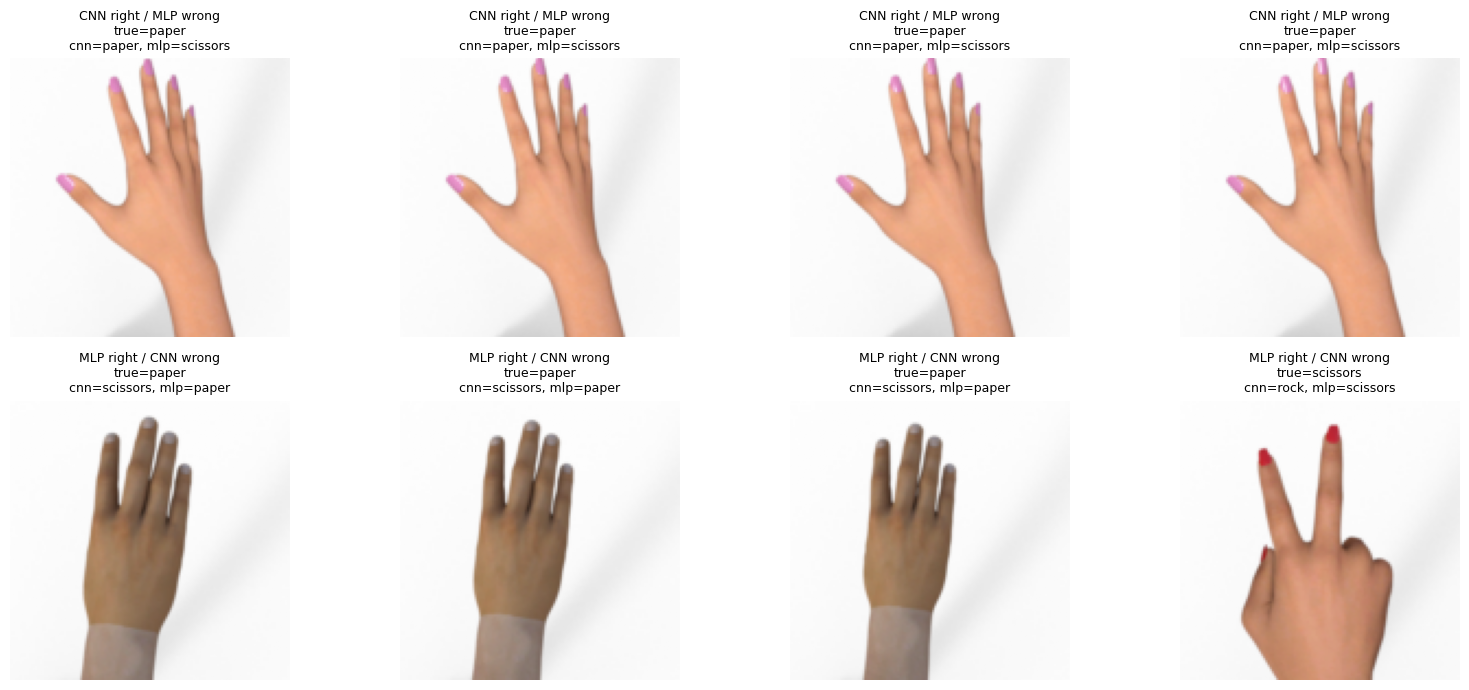

saved: /content/drive/MyDrive/dsai5207/figures/error_cases.png


In [ ]:
# error analysis: compare CNN and MLP
import os
import numpy as np
import matplotlib.pyplot as plt
import torch


# keep MLP image size the same as before
mlp_img_size = improved_config["img_size"] if "improved_config" in globals() else 64
mlp_num_classes = improved_config["num_classes"] if "improved_config" in globals() else 3
mlp_dropout = improved_config["dropout"] if "improved_config" in globals() else 0.3

# MLP test loader
mlp_transform = transforms.Compose([
    transforms.Resize((mlp_img_size, mlp_img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
    transforms.Lambda(lambda x: x.view(-1))
])

mlp_test_dataset = datasets.ImageFolder(test_dir, transform=mlp_transform)
mlp_test_loader = DataLoader(mlp_test_dataset, batch_size=64, shuffle=False)

# choose which MLP model file to use
mlp_model_path = os.path.join(models_dir, "mlp_improved_ratio_100.pt")
if not os.path.exists(mlp_model_path):
    mlp_model_path = os.path.join(models_dir, "mlp_model.pt")

print("use mlp model:", mlp_model_path)

# rebuild the MLP with the same input size as training
sample_x, _ = mlp_test_dataset[0]
input_dim = sample_x.numel()

if "ImprovedMLP" in globals():
    mlp_model = ImprovedMLP(
        input_dim=input_dim,
        num_classes=mlp_num_classes,
        dropout=mlp_dropout
    ).to(device)
else:
    raise RuntimeError("ImprovedMLP class was not found. Please run the ImprovedMLP definition cell first.")

mlp_state = torch.load(mlp_model_path, map_location=device, weights_only=True)
mlp_model.load_state_dict(mlp_state)
mlp_model.eval()

# CNN test loader
raw_test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

raw_test_dataset = datasets.ImageFolder(test_dir, transform=raw_test_transform)
raw_test_loader = DataLoader(raw_test_dataset, batch_size=64, shuffle=False)

cnn_model.eval()

# save data for comparison
all_true = []
all_mlp_pred = []
all_cnn_pred = []
all_imgs = []

with torch.no_grad():
    # MLP prediction
    for x_mlp, y in mlp_test_loader:
        x_mlp = x_mlp.to(device)
        logits = mlp_model(x_mlp)
        pred = torch.argmax(logits, dim=1)
        all_mlp_pred.extend(pred.cpu().numpy().tolist())

    # CNN prediction + save images
    for x_cnn, y in raw_test_loader:
        x_cnn = x_cnn.to(device)
        logits = cnn_model(x_cnn)
        pred = torch.argmax(logits, dim=1)

        all_true.extend(y.numpy().tolist())
        all_cnn_pred.extend(pred.cpu().numpy().tolist())
        all_imgs.extend(x_cnn.cpu().numpy())

all_true = np.array(all_true)
all_mlp_pred = np.array(all_mlp_pred)
all_cnn_pred = np.array(all_cnn_pred)
all_imgs = np.array(all_imgs)

# two typical groups
idx_cnn_right_mlp_wrong = np.where((all_cnn_pred == all_true) & (all_mlp_pred != all_true))[0]
idx_mlp_right_cnn_wrong = np.where((all_mlp_pred == all_true) & (all_cnn_pred != all_true))[0]

print("CNN right / MLP wrong:", len(idx_cnn_right_mlp_wrong))
print("MLP right / CNN wrong:", len(idx_mlp_right_cnn_wrong))

# show up to 4 examples for each case
show_n = 4
sel_a = idx_cnn_right_mlp_wrong[:show_n]
sel_b = idx_mlp_right_cnn_wrong[:show_n]

idx_to_class = {v: k for k, v in raw_test_dataset.class_to_idx.items()}

fig, axes = plt.subplots(2, show_n, figsize=(4 * show_n, 7))

for i in range(show_n):
    axes[0, i].axis("off")
    axes[1, i].axis("off")

for i, idx in enumerate(sel_a):
    img = np.transpose(all_imgs[idx], (1, 2, 0))
    axes[0, i].imshow(np.clip(img, 0, 1))
    axes[0, i].set_title(
        f"CNN right / MLP wrong\n"
        f"true={idx_to_class[all_true[idx]]}\n"
        f"cnn={idx_to_class[all_cnn_pred[idx]]}, mlp={idx_to_class[all_mlp_pred[idx]]}",
        fontsize=9
    )
    axes[0, i].axis("off")

for i, idx in enumerate(sel_b):
    img = np.transpose(all_imgs[idx], (1, 2, 0))
    axes[1, i].imshow(np.clip(img, 0, 1))
    axes[1, i].set_title(
        f"MLP right / CNN wrong\n"
        f"true={idx_to_class[all_true[idx]]}\n"
        f"cnn={idx_to_class[all_cnn_pred[idx]]}, mlp={idx_to_class[all_mlp_pred[idx]]}",
        fontsize=9
    )
    axes[1, i].axis("off")

plt.tight_layout()

error_fig_path = os.path.join(figures_dir, "error_cases.png")
plt.savefig(error_fig_path, dpi=180, bbox_inches="tight")
plt.show()

print("saved:", error_fig_path)


***4. Repeated Runs + Statistics***



4.1 Experimental setup and config

In [ ]:
import torch

# Repeated-runs seeds
seeds = [1, 2, 3]
print("seeds:", seeds)

# Using existing setup & config and define them
if "ratios" in globals():
  print("ratios:", ratios)
else:
  print("Warning: 'ratios' is not found. Check whether previous sections have been run.")

if "mlp_cfg" not in globals():
  mlp_cfg = {
      "batch_size": 32,
      "img_size": 64,
      "epochs": 20,
      "lr": 5e-4,
      "weight_decay": 1e-4,
      "dropout": 0.3,
      "num_classes": 3,
      "patience": 5
  }

if "cnn_cfg" not in globals():
  cnn_cfg = {
      "batch_size": 32,
      "img_size": 128,
      "epochs": 20,
      "lr": 1e-3,
      "weight_decay": 0,
      "base_channels": 32,
      "num_classes": 3
  }

print("Improved MLP config:", mlp_cfg)
print("CNN config:", cnn_cfg)

seeds: [1, 2, 3]
ratios: [0.05, 0.1, 0.2, 0.5, 1.0]
Improved MLP config: {'batch_size': 32, 'img_size': 64, 'epochs': 20, 'lr': 0.0005, 'weight_decay': 0.0001, 'dropout': 0.3, 'num_classes': 3, 'patience': 5}
CNN config: {'batch_size': 32, 'img_size': 128, 'epochs': 20, 'lr': 0.001, 'weight_decay': 0, 'base_channels': 32, 'num_classes': 3}


4.2 Define functions for data procession and evaluation

In [ ]:
import random
import numpy as np
import torch
from sklearn.metrics import f1_score
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

def set_seeds(seed):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
  torch.backends.cudnn.deterministic= True
  torch.backends.cudnn.benchmark = False

# Stratified Sampling by Class
def sample_data_by_ratio(dataset, ratio, seed):
  rng =  random.Random(seed)
  labels = [y for _,y in dataset.samples]
  classes = set(labels)
  selected = []

  for c in classes:
    idx = [i for i, (x, y) in enumerate(dataset.samples) if y==c]
    rng.shuffle(idx)
    k = max(1, int(len(idx) * ratio))
    selected += idx[:k]

  rng.shuffle(selected)
  return selected

def build_transform(size, normalize=False):
  trans = [
      transforms.Resize((size, size)),
      transforms.ToTensor()
  ]
  if normalize:
    trans.append(
        transforms.Normalize(
            mean = [0.5, 0.5, 0.5],
            std = [0.5, 0.5, 0.5]
        )
    )
  return transforms.Compose(trans)

def load_dataset(ratio, seed, size, batch, normalize=False):
  transform = build_transform(size, normalize)

  train_ds = datasets.ImageFolder(train_dir, transform=transform)
  val_ds = datasets.ImageFolder(val_dir, transform=transform)
  test_ds = datasets.ImageFolder(test_dir, transform=transform)

  if ratio < 1.0:
    idx = sample_data_by_ratio(train_ds, ratio, seed)
    train_ds = Subset(train_ds, idx)

  train_loader = DataLoader(train_ds, batch, shuffle=True, num_workers=2)
  val_loader = DataLoader(val_ds, batch, shuffle=False, num_workers=2)
  test_loader = DataLoader(test_ds, batch, shuffle=False, num_workers=2)

  return train_loader, val_loader, test_loader, len(train_ds)

def evaluate(model, loader, criterion):
  model.eval()
  total_loss = 0.0
  total_count = 0
  all_preds = []
  all_labels = []

  with torch.no_grad():
    for x,y in loader:
      x, y = x.to(device), y.to(device)
      out = model(x)
      loss = criterion(out, y)

      batch_size_now = y.size(0)
      total_loss += loss.item() * batch_size_now
      total_count += batch_size_now

      all_preds += out.argmax(dim=1).cpu().tolist()
      all_labels += y.cpu().tolist()

  avg_loss = total_loss / total_count
  acc = np.mean(np.array(all_preds) == np.array(all_labels))
  f1 = f1_score(all_labels, all_preds, average="macro")

  return avg_loss, acc, f1

4.3 Single-Run training for Improved MLP

In [ ]:
import copy
import torch.nn as nn
import torch.optim as optim

def train_improved_mlp_once(seed, ratio, cfg):
  set_seeds(seed)

  train_loader, val_loader, test_loader, train_size = load_dataset(
      ratio = ratio,
      seed = seed,
      size = cfg["img_size"],
      batch = cfg["batch_size"],
      normalize = True
  )

  model = ImprovedMLP(
      input_dim = 3 * cfg["img_size"] * cfg["img_size"],
      num_classes = cfg["num_classes"],
      dropout = cfg["dropout"]
  ).to(device)

  criterion = nn.CrossEntropyLoss()

  optimizer = optim.Adam(
      model.parameters(),
      lr = cfg["lr"],
      weight_decay = cfg["weight_decay"]
  )

  best_model = None
  best_val_acc = -1.0
  best_val_f1 = -1.0
  best_epoch = -1
  patience_counter = 0

  for epoch in range(cfg["epochs"]):
    model.train()

    for x, y in train_loader:
      x, y = x.to(device), y.to(device)
      optimizer.zero_grad()
      out = model(x)
      loss = criterion(out, y)
      loss.backward()
      optimizer.step()

    val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion)

    # Save best model (Prioritize val_acc, break ties with val_f1)
    if (val_acc > best_val_acc) or (val_acc == best_val_acc and val_f1 > best_val_f1):
      best_val_acc = val_acc
      best_val_f1 = val_f1
      best_epoch = epoch + 1
      best_model = copy.deepcopy(model.state_dict())
      patience_counter = 0
    else:
      patience_counter += 1
      if patience_counter >= cfg["patience"]:
        break

  model.load_state_dict(best_model)
  test_loss, test_acc, test_f1 = evaluate(model, test_loader, criterion)

  return {
      "seed": seed,
      "data_ratio": ratio,
      "train_size": train_size,
      "best_epoch": best_epoch,
      "best_val_accuracy": best_val_acc,
      "best_val_macro_f1": best_val_f1,
      "test_loss": test_loss,
      "test_accuracy": test_acc,
      "test_macro_f1": test_f1
  }

4.4 Single-Run training for CNN

In [ ]:
def train_cnn_once(seed, ratio, cfg):
  set_seeds(seed)

  train_loader, val_loader, test_loader, train_size = load_dataset(
      ratio = ratio,
      seed = seed,
      size = cfg["img_size"],
      batch = cfg["batch_size"],
      normalize = True
  )

  model = SimpleCNN(
      num_classes = cfg["num_classes"],
      base_channels = cfg["base_channels"]
  ).to(device)

  criterion = nn.CrossEntropyLoss()

  optimizer = optim.Adam(
      model.parameters(),
      lr = cfg["lr"],
      weight_decay = cfg["weight_decay"]
  )

  # Compatible with no patience config
  patience = cfg.get("patience", cfg["epochs"])

  best_model = None
  best_val_acc = -1.0
  best_val_f1 = -1.0
  best_epoch = -1
  patience_counter = 0

  for epoch in range(cfg["epochs"]):
    model.train()

    for x, y in train_loader:
      x, y = x.to(device), y.to(device)
      optimizer.zero_grad()
      out = model(x)
      loss = criterion(out, y)
      loss.backward()
      optimizer.step()

    val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion)

    # Save best model (Prioritize val_acc, break ties with val_f1)
    if (val_acc > best_val_acc) or (val_acc == best_val_acc and val_f1 > best_val_f1):
      best_val_acc = val_acc
      best_val_f1 = val_f1
      best_epoch = epoch + 1
      best_model = copy.deepcopy(model.state_dict())
      patience_counter = 0
    else:
      patience_counter += 1
      if patience_counter >= patience:
        break

  model.load_state_dict(best_model)
  test_loss, test_acc, test_f1 = evaluate(model, test_loader, criterion)

  return {
      "seed": seed,
      "data_ratio": ratio,
      "train_size": train_size,
      "best_epoch": best_epoch,
      "best_val_accuracy": best_val_acc,
      "best_val_macro_f1": best_val_f1,
      "test_loss": test_loss,
      "test_accuracy": test_acc,
      "test_macro_f1": test_f1
  }

4.5 Repeated runs for Improved MLP / CNN

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

if torch.cuda.is_available():
  print("GPU name:", torch.cuda.get_device_name(0))

device: cuda
GPU name: Tesla T4


In [ ]:
import pandas as pd

def repeated_runs(train_fn, seeds, ratios, cfg, model_name):
  results = []

  print(f"\n====== Repeated Runs for {model_name} ======")

  for ratio in ratios:
    print(f"\n--- When Data Ratio = {ratio} ---")

    for seed in seeds:
      result = train_fn(seed=seed, ratio=ratio, cfg=cfg)
      result["model"] = model_name
      results.append(result)

      print(
          f"seed={seed}",
          f"train_size={result['train_size']}",
          f"best_epoch={result['best_epoch']}",
          f"test_acc={result['test_accuracy']:.4f}",
          f"test_f1={result['test_macro_f1']:.4f}"
      )

  return pd.DataFrame(results)

In [ ]:
# Repeated runs for Improved MLP
mlp_results_df = repeated_runs(
    train_fn = train_improved_mlp_once,
    seeds = seeds,
    ratios = ratios,
    cfg = mlp_cfg,
    model_name = "Improved MLP"
)

print("\nMLP repeated-run results:")
print(mlp_results_df.head())


====== Repeated Runs for Improved MLP ======

--- When Data Ratio = 0.05 ---
seed=1 train_size=126 best_epoch=12 test_acc=0.5672 test_f1=0.5714
seed=2 train_size=126 best_epoch=5 test_acc=0.4194 test_f1=0.3233
seed=3 train_size=126 best_epoch=1 test_acc=0.3333 test_f1=0.1667

--- When Data Ratio = 0.1 ---
seed=1 train_size=252 best_epoch=12 test_acc=0.5188 test_f1=0.4818
seed=2 train_size=252 best_epoch=7 test_acc=0.5054 test_f1=0.4143
seed=3 train_size=252 best_epoch=15 test_acc=0.5161 test_f1=0.4945

--- When Data Ratio = 0.2 ---
seed=1 train_size=504 best_epoch=5 test_acc=0.6183 test_f1=0.6251
seed=2 train_size=504 best_epoch=11 test_acc=0.5108 test_f1=0.4274
seed=3 train_size=504 best_epoch=7 test_acc=0.6102 test_f1=0.5949

--- When Data Ratio = 0.5 ---
seed=1 train_size=1260 best_epoch=2 test_acc=0.4812 test_f1=0.3982
seed=2 train_size=1260 best_epoch=4 test_acc=0.6183 test_f1=0.6165
seed=3 train_size=1260 best_epoch=7 test_acc=0.5591 test_f1=0.5510

--- When Data Ratio = 1.0 ---

In [ ]:
# Repeated runs for CNN
cnn_results_df = repeated_runs(
    train_fn = train_cnn_once,
    seeds = seeds,
    ratios = ratios,
    cfg = cnn_cfg,
    model_name = "CNN"
)

print("\nCNN repeated-run results:")
print(cnn_results_df.head())


====== Repeated Runs for CNN ======

--- When Data Ratio = 0.05 ---
seed=1 train_size=126 best_epoch=18 test_acc=0.6909 test_f1=0.6781
seed=2 train_size=126 best_epoch=16 test_acc=0.7903 test_f1=0.7908
seed=3 train_size=126 best_epoch=16 test_acc=0.7177 test_f1=0.7142

--- When Data Ratio = 0.1 ---
seed=1 train_size=252 best_epoch=16 test_acc=0.8360 test_f1=0.8338
seed=2 train_size=252 best_epoch=18 test_acc=0.8360 test_f1=0.8318
seed=3 train_size=252 best_epoch=17 test_acc=0.8387 test_f1=0.8400

--- When Data Ratio = 0.2 ---
seed=1 train_size=504 best_epoch=6 test_acc=0.8737 test_f1=0.8733
seed=2 train_size=504 best_epoch=8 test_acc=0.8172 test_f1=0.8153
seed=3 train_size=504 best_epoch=10 test_acc=0.7903 test_f1=0.7885

--- When Data Ratio = 0.5 ---
seed=1 train_size=1260 best_epoch=9 test_acc=0.8522 test_f1=0.8516
seed=2 train_size=1260 best_epoch=3 test_acc=0.8629 test_f1=0.8614
seed=3 train_size=1260 best_epoch=8 test_acc=0.8817 test_f1=0.8798

--- When Data Ratio = 1.0 ---
seed=

4.6 Statistical summary table

In [ ]:
# Combine all results
all_results_df = pd.concat([mlp_results_df, cnn_results_df], ignore_index=True)

print("\nCombined repeated-run results")
print(all_results_df.head())

all_results_path = os.path.join(runs_dir, "all_results.csv")
all_results_df.to_csv(all_results_path, index=False)
print("saved:", all_results_path)


Combined repeated-run results
   seed  data_ratio  train_size  best_epoch  best_val_accuracy  \
0     1        0.05         126          12           0.636364   
1     2        0.05         126           5           0.484848   
2     3        0.05         126           1           0.333333   
3     1        0.10         252          12           0.696970   
4     2        0.10         252           7           0.666667   

   best_val_macro_f1  test_loss  test_accuracy  test_macro_f1         model  
0           0.630994   0.961352       0.567204       0.571371  Improved MLP  
1           0.402402   1.793939       0.419355       0.323337  Improved MLP  
2           0.166667   3.228043       0.333333       0.166667  Improved MLP  
3           0.690773   1.121444       0.518817       0.481848  Improved MLP  
4           0.669841   0.997846       0.505376       0.414281  Improved MLP  
saved: /content/drive/MyDrive/dsai5207/runs/all_results.csv


In [ ]:
# Statistical table: mean and std
stats_df = all_results_df.groupby(["model", "data_ratio"]).agg(
    mean_test_accuracy = ("test_accuracy", "mean"),
    std_test_accuracy = ("test_accuracy", "std"),
    mean_test_f1 = ("test_macro_f1", "mean"),
    std_test_f1 = ("test_macro_f1", "std"),
    mean_best_epoch = ("best_epoch", "mean")
).reset_index()

metrics_summary_df = stats_df.round({
    "mean_test_accuracy": 4,
    "std_test_accuracy": 4,
    "mean_test_f1": 4,
    "std_test_f1": 4,
    "mean_best_epoch": 2
})

print("\nStatistical summary of repeated runs")
print(metrics_summary_df)

metrics_summary_path = os.path.join(runs_dir, "metrics_summary.csv")
metrics_summary_df.to_csv(metrics_summary_path, index=False)
print("saved:", metrics_summary_path)


Statistical summary of repeated runs
          model  data_ratio  mean_test_accuracy  std_test_accuracy  \
0           CNN        0.05              0.7330             0.0515   
1           CNN        0.10              0.8369             0.0016   
2           CNN        0.20              0.8271             0.0425   
3           CNN        0.50              0.8656             0.0150   
4           CNN        1.00              0.8396             0.0205   
5  Improved MLP        0.05              0.4400             0.1183   
6  Improved MLP        0.10              0.5134             0.0071   
7  Improved MLP        0.20              0.5797             0.0599   
8  Improved MLP        0.50              0.5529             0.0688   
9  Improved MLP        1.00              0.6102             0.0396   

   mean_test_f1  std_test_f1  mean_best_epoch  
0        0.7277       0.0575            16.67  
1        0.8352       0.0043            17.00  
2        0.8257       0.0433             8.00  

4.7 Performance and Stability Visualization

In [ ]:
import matplotlib.pyplot as plt

models = ["Improved MLP", "CNN"]
ratio_labels = [f"{int(r*100)}%" for r in ratios]

mlp_stats = metrics_summary_df[metrics_summary_df['model'] == "Improved MLP"]
cnn_stats = metrics_summary_df[metrics_summary_df['model'] == "CNN"]

mlp_stats = mlp_stats.sort_values("data_ratio")
cnn_stats = cnn_stats.sort_values("data_ratio")

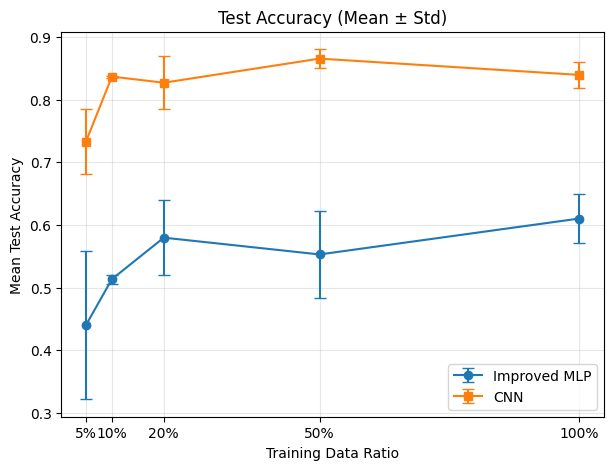

saved: /content/drive/MyDrive/dsai5207/figures/mean_test_acc.png


In [ ]:
# Test Accuracy (Mean ± Std)
plt.figure(figsize=(7, 5))

plt.errorbar(
    mlp_stats["data_ratio"],
    mlp_stats["mean_test_accuracy"],
    yerr = mlp_stats["std_test_accuracy"],
    marker = "o",
    capsize = 4,
    label = "Improved MLP"
)

plt.errorbar(
    cnn_stats["data_ratio"],
    cnn_stats["mean_test_accuracy"],
    yerr = cnn_stats["std_test_accuracy"],
    marker = "s",
    capsize = 4,
    label = "CNN"
)

plt.xticks(ratios, ratio_labels)
plt.xlabel("Training Data Ratio")
plt.ylabel("Mean Test Accuracy")
plt.title("Test Accuracy (Mean ± Std)")

plt.legend()
plt.grid(True, alpha=0.3)

mean_acc_fig_path = os.path.join(figures_dir, "mean_test_acc.png")
plt.savefig(mean_acc_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("saved:", mean_acc_fig_path)

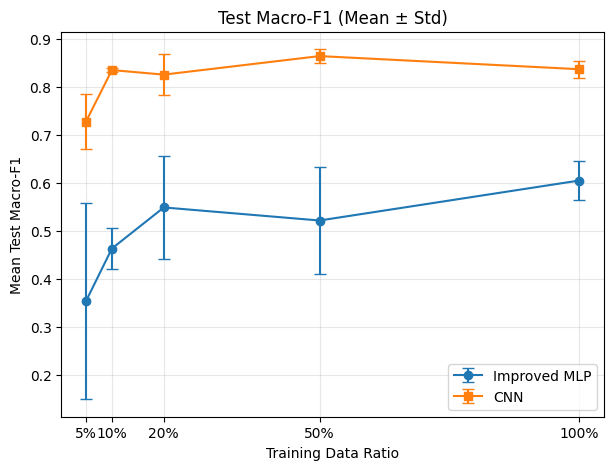

saved: /content/drive/MyDrive/dsai5207/figures/mean_macro_f1.png


In [ ]:
# Test Macro-F1 (Mean ± Std)
plt.figure(figsize=(7, 5))

plt.errorbar(
    mlp_stats["data_ratio"],
    mlp_stats["mean_test_f1"],
    yerr = mlp_stats["std_test_f1"],
    marker = "o",
    capsize = 4,
    label = "Improved MLP"
)

plt.errorbar(
    cnn_stats["data_ratio"],
    cnn_stats["mean_test_f1"],
    yerr = cnn_stats["std_test_f1"],
    marker = "s",
    capsize = 4,
    label = "CNN"
)

plt.xticks(ratios, ratio_labels)
plt.xlabel("Training Data Ratio")
plt.ylabel("Mean Test Macro-F1")
plt.title("Test Macro-F1 (Mean ± Std)")

plt.legend()
plt.grid(True, alpha=0.3)

mean_f1_fig_path = os.path.join(figures_dir, "mean_macro_f1.png")
plt.savefig(mean_f1_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("saved:", mean_f1_fig_path)

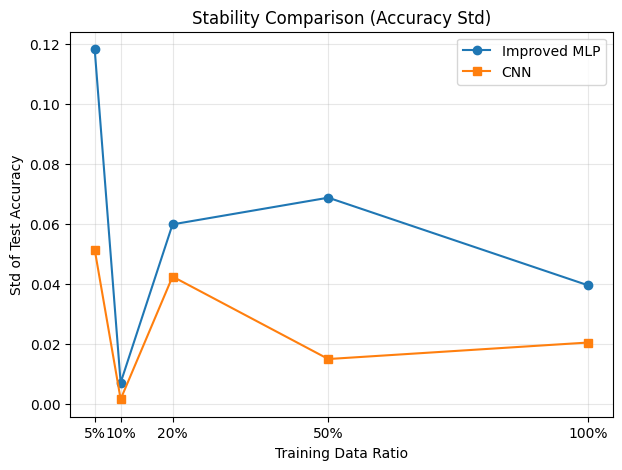

saved: /content/drive/MyDrive/dsai5207/figures/std_test_acc.png


In [ ]:
# Stability Comparison (Accuracy Std)
plt.figure(figsize=(7, 5))

plt.plot(
    mlp_stats["data_ratio"],
    mlp_stats["std_test_accuracy"],
    marker = "o",
    label = "Improved MLP"
)

plt.plot(
    cnn_stats["data_ratio"],
    cnn_stats["std_test_accuracy"],
    marker = "s",
    label = "CNN"
)

plt.xticks(ratios, ratio_labels)
plt.xlabel("Training Data Ratio")
plt.ylabel("Std of Test Accuracy")
plt.title("Stability Comparison (Accuracy Std)")

plt.legend()
plt.grid(True, alpha=0.3)

std_acc_fig_path = os.path.join(figures_dir, "std_test_acc.png")
plt.savefig(std_acc_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("saved:", std_acc_fig_path)

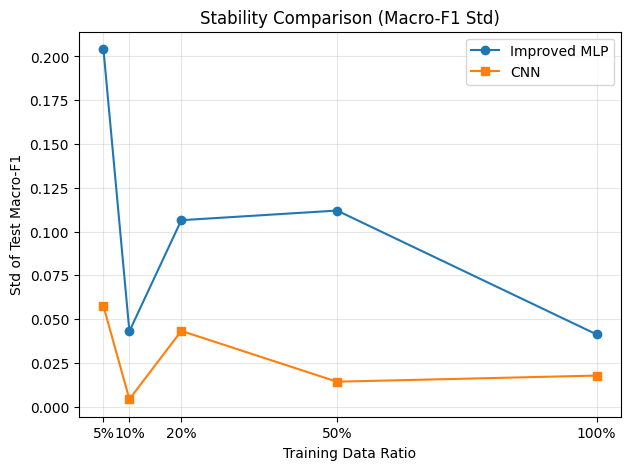

saved: /content/drive/MyDrive/dsai5207/figures/std_test_f1.png


In [ ]:
# Stability Comparison (Macro-F1 Std)
plt.figure(figsize=(7, 5))

plt.plot(
    mlp_stats["data_ratio"],
    mlp_stats["std_test_f1"],
    marker = "o",
    label = "Improved MLP"
)

plt.plot(
    cnn_stats["data_ratio"],
    cnn_stats["std_test_f1"],
    marker = "s",
    label = "CNN"
)

plt.xticks(ratios, ratio_labels)
plt.xlabel("Training Data Ratio")
plt.ylabel("Std of Test Macro-F1")
plt.title("Stability Comparison (Macro-F1 Std)")

plt.legend()
plt.grid(True, alpha=0.3)

std_f1_fig_path = os.path.join(figures_dir, "std_test_f1.png")
plt.savefig(std_f1_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("saved:", std_f1_fig_path)